In [1]:
%pip install tensorflow


  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached grpcio-1.80.0-cp313-cp313-win_amd64.whl.metadata (3.9 kB)
  Using cached keras-3.14.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached h5py-3.14.0-cp313-cp313-win_amd64.whl.metadata (2.7 kB)
  Using cached ml_dtypes-0.5.4-cp313-cp313-win_amd64.whl.metadata (9.2 kB)
  Using cach

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [2]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [11]:



# ====================================================
# Linear Regression using Deep Neural Network
# Boston Housing Price Prediction
# ====================================================

# =========================
# Step 1: Import Libraries
# =========================

import numpy as np              # For numerical calculations
import pandas as pd             # For handling dataset
import matplotlib.pyplot as plt # For plotting graphs

# For splitting dataset
from sklearn.model_selection import train_test_split

# For scaling data (important for neural networks)
from sklearn.preprocessing import StandardScaler

# TensorFlow for Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [12]:
# =========================
# Step 2: Load Dataset
# =========================

# 👉 Keep CSV file in SAME folder as notebook
# OR give full path (Ubuntu example)
# "/home/username/Desktop/1_boston_housing.csv"

#df = pd.read_csv('C:\Users\lenovo\OneDrive\Pictures\DL-exam\DL-1\1_boston_housing.csv')
df = pd.read_csv(r'C:\Users\lenovo\OneDrive\Pictures\DL-exam\DL-1\1_boston_housing.csv')

# Remove unwanted quotes from column names
df.columns = df.columns.str.replace('"', '')

# Display first 5 rows
print("Dataset Preview:")
print(df.head())


Dataset Preview:
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


In [13]:
# =========================
# Step 3: Split Features & Target
# =========================

# X → input features (all columns except MEDV)
X = df.drop("MEDV", axis=1)

# y → target (house price)
y = df["MEDV"]

print("\nShape of data:")
print("X:", X.shape, " y:", y.shape)


Shape of data:
X: (506, 13)  y: (506,)


In [14]:
# =========================
# Step 4: Train-Test Split
# =========================

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [15]:
# =========================
# Step 5: Feature Scaling
# =========================

# Neural networks work better with scaled data
scaler = StandardScaler()

# Fit on training data, transform both
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
# =========================
# Step 6: Build Neural Network
# =========================

# Create model
model = Sequential()

# Hidden Layer 1 (64 neurons)
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

# Hidden Layer 2 (32 neurons)
model.add(Dense(32, activation='relu'))

# Output Layer (1 neuron → regression output)
model.add(Dense(1, activation='linear'))

# Compile model
model.compile(
    optimizer='adam',   # optimizer
    loss='mse',         # loss function for regression
    metrics=['mae']     # evaluation metric
)

# Show model structure
print("\nModel Summary:")
model.summary()

D:\anaconda-navigator\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Model Summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# =========================
# Step 7: Train Model
# =========================

print("\nTraining model...")

history = model.fit(
    X_train, y_train,
    epochs=100,          # number of iterations
    batch_size=16,       # batch size
    validation_split=0.2,# validation data
    verbose=1
)


Training model...
Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 574.9604 - mae: 22.0357 - val_loss: 489.8757 - val_mae: 20.5218
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 506.1187 - mae: 20.3710 - val_loss: 409.4335 - val_mae: 18.4994
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 393.6690 - mae: 17.5708 - val_loss: 283.3937 - val_mae: 14.9848
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 247.2645 - mae: 13.3596 - val_loss: 147.0737 - val_mae: 10.2427
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 126.6305 - mae: 8.9913 - val_loss: 66.7635 - val_mae: 6.2586
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 71.1110 - mae: 6.7879 - val_loss: 40.7023 - val_mae: 4.6207
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 46.6344 - mae: 5.3066 - val_loss: 31.3662 - val_mae: 3.9437
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 34.3071 - mae: 4.4321 - val_loss: 27.6075 - val_mae: 3.6237
Epoch 9/

In [18]:
# =========================
# Step 8: Evaluate Model
# =========================

print("\nEvaluating model...")

loss, mae = model.evaluate(X_test, y_test)

print("Test Loss (MSE):", loss)
print("Test MAE:", mae)



Evaluating model...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 12.3193 - mae: 2.2989
Test Loss (MSE): 12.319252014160156
Test MAE: 2.2989470958709717


In [19]:
# =========================
# Step 9: Predictions
# =========================

print("\nSample Predictions:")

y_pred = model.predict(X_test)

# Compare actual vs predicted
for i in range(5):
    print(f"Actual: {y_test.iloc[i]:.2f} | Predicted: {y_pred[i][0]:.2f}")





Sample Predictions:
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Actual: 23.60 | Predicted: 27.96
Actual: 32.40 | Predicted: 34.57
Actual: 13.60 | Predicted: 17.44
Actual: 22.80 | Predicted: 25.73
Actual: 16.10 | Predicted: 15.90


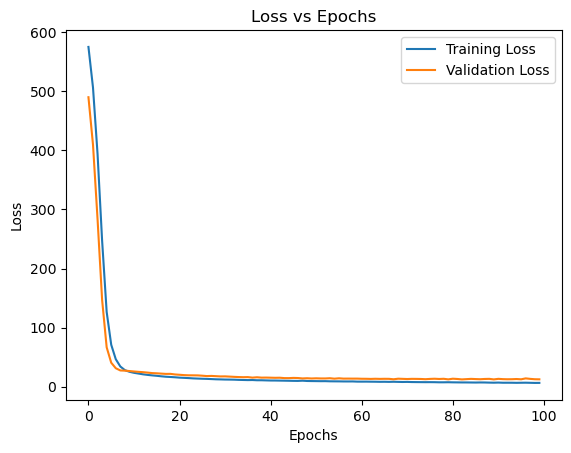

In [20]:
# =========================
# Step 10: Plot Graph
# =========================

# Plot training loss vs validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()